Load the dataset and initial inspection

In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/sample_data/Superstore.csv', encoding='ISO-8859-1')

# Show first 5 rows
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Basic info and structure

In [3]:
# Get general info about the dataset (columns, data types, nulls)
df.info()

# Show basic statistics for numerical columns
df.describe()

# Show all column names
df.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

 Check for missing values

In [4]:
# Count missing values in each column
df.isnull().sum()


,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


Drop unnecessary columns

In [5]:
columns_to_drop = [
    'Row ID',
    'Order ID',
    'Customer ID',
    'Customer Name',
    'Country',
    'City',
    'State',
    'Postal Code',
    'Region',
    'Product ID',
    'Product Name',
    'Order Date',
    'Ship Date'
]

df = df.drop(columns=columns_to_drop)


Check the remaining columns

In [6]:
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Category      9994 non-null   object 
 3   Sub-Category  9994 non-null   object 
 4   Sales         9994 non-null   float64
 5   Quantity      9994 non-null   int64  
 6   Discount      9994 non-null   float64
 7   Profit        9994 non-null   float64
dtypes: float64(3), int64(1), object(4)
memory usage: 624.8+ KB


## Prepare features and target
Target variable

In [ ]:
y = df['Segment']


Features (predictors):

In [7]:
X = df.drop(columns=['Segment'])  # Drop target column from features


Encode categorical variables

In [15]:
X_encoded = pd.get_dummies(X, drop_first=True)


## Train/Test Split


In [16]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train target distribution:\n", y_train.value_counts(normalize=True))
print("Test target distribution:\n", y_test.value_counts(normalize=True))


Train shape: (7995, 25)
Test shape: (1999, 25)
Train target distribution:
 Segment
Consumer       0.519450
Corporate      0.302189
Home Office    0.178361
Name: proportion, dtype: float64
Test target distribution:
 Segment
Consumer       0.519260
Corporate      0.302151
Home Office    0.178589
Name: proportion, dtype: float64


## Logistic Regression

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.2891445722861431

Classification Report:
               precision    recall  f1-score   support

    Consumer       0.51      0.21      0.30      1038
   Corporate       0.28      0.32      0.30       604
 Home Office       0.19      0.46      0.27       357

    accuracy                           0.29      1999
   macro avg       0.33      0.33      0.29      1999
weighted avg       0.38      0.29      0.29      1999



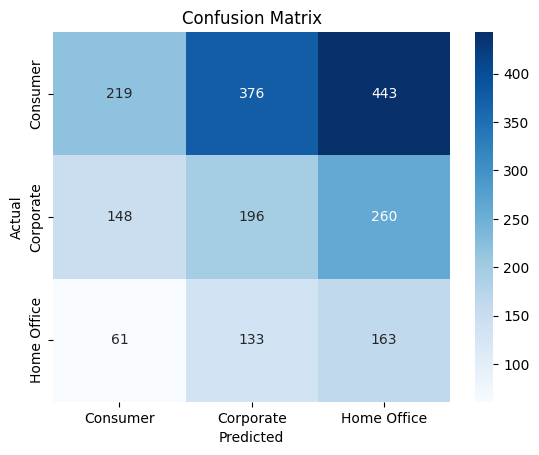

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 2: Train Logistic Regression (multinomial)
model = LogisticRegression(
    multi_class='multinomial',  # better for multiclass problems
    solver='lbfgs',             # compatible solver
    max_iter=3000,              # more iterations to ensure convergence
    class_weight='balanced'     # handles class imbalance
)

model.fit(X_train_scaled, y_train)

# Step 3: Predict
y_pred = model.predict(X_test_scaled)

# Step 4: Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
conf_mat = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Accuracy: 0.43871935967983994

Classification Report:
               precision    recall  f1-score   support

    Consumer       0.53      0.67      0.59      1038
   Corporate       0.30      0.24      0.27       604
 Home Office       0.16      0.09      0.11       357

    accuracy                           0.44      1999
   macro avg       0.33      0.33      0.32      1999
weighted avg       0.39      0.44      0.41      1999



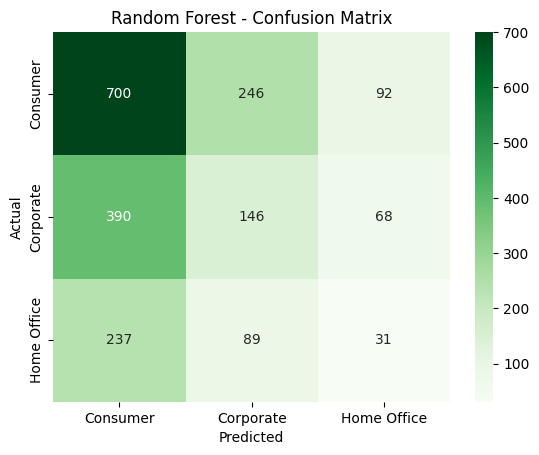

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train the model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# Confusion matrix
conf_mat = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Greens',
            xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [19]:
y.value_counts(normalize=True)


,proportion
Segment,
Consumer,0.519412
Corporate,0.302181
Home Office,0.178407


class_weight in Random Forest:

Accuracy: 0.4352176088044022

Classification Report:
               precision    recall  f1-score   support

    Consumer       0.53      0.65      0.58      1038
   Corporate       0.31      0.26      0.28       604
 Home Office       0.19      0.12      0.14       357

    accuracy                           0.44      1999
   macro avg       0.34      0.34      0.34      1999
weighted avg       0.40      0.44      0.41      1999



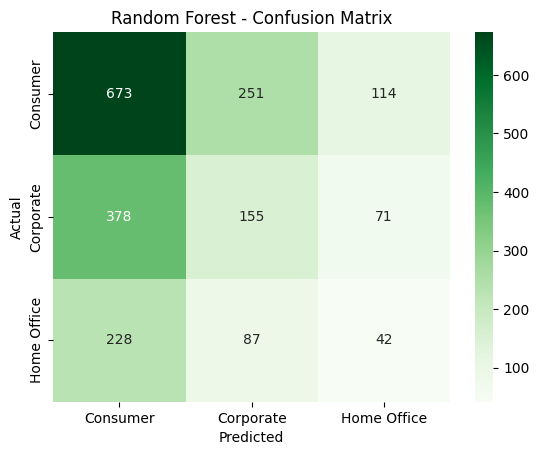

In [21]:
# Train the model
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# Confusion matrix
conf_mat = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Greens',
            xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Although the application of class weighting slightly improved class balance in prediction, the improvement is not sufficient for a reliable classifier. The current features likely lack the discriminative power required to separate the customer segments effectively.



## Feature Engineering

Add New Features

In [30]:
df['Profit_Sales_Ratio'] = df['Profit'] / (df['Sales'] + 1e-6)  # To avoid division by zero


In [24]:
# Step 1: Load the original dataset again
import pandas as pd

df = pd.read_csv("/content/sample_data/Superstore.csv", encoding='latin1')  # یا utf-8-sig اگه لازم شد

# Step 2: Clean Postal Code again (if needed)
df["Postal Code"] = df["Postal Code"].fillna(0).astype(int)

# Step 3: Convert date columns
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True, errors='coerce')

# Step 4: Drop any remaining NaN rows just to be safe (optional)
df.dropna(inplace=True)


In [25]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Order_Month'] = df['Order Date'].dt.month
df['Order_Year'] = df['Order Date'].dt.year


In [26]:
df['High_Discount'] = (df['Discount'] > 0.3).astype(int)



In [27]:
df['Sales_Level'] = pd.cut(df['Sales'],
                           bins=[-1, 100, 500, df['Sales'].max()],
                           labels=['Low', 'Medium', 'High'])


In [31]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Order_Month,Order_Year,High_Discount,Sales_Level,Profit_Sales_Ratio
0,1,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.960,2,0.0,41.9136,8,2016,0,Medium,0.1600
1,2,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.940,3,0.0,219.5820,8,2016,0,High,0.3000
13,14,CA-2016-161389,2016-05-12,2016-10-12,Standard Class,IM-15070,Irene Maddox,Consumer,United States,Seattle,...,Fellowes PB200 Plastic Comb Binding Machine,407.976,3,0.2,132.5922,5,2016,0,Medium,0.3250
35,36,CA-2016-117590,2016-08-12,2016-10-12,First Class,GH-14485,Gene Hale,Corporate,United States,Richardson,...,GE 30524EE4,1097.544,7,0.2,123.4737,8,2016,0,High,0.1125
36,37,CA-2016-117590,2016-08-12,2016-10-12,First Class,GH-14485,Gene Hale,Corporate,United States,Richardson,...,"Electrix Architect's Clamp-On Swing Arm Lamp, ...",190.920,5,0.6,-147.9630,8,2016,1,Medium,-0.7750


In [33]:
# Target variable
y = df['Segment']

# Feature columns (including new features + selected old ones)
X = df[[
    'Ship Mode', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit',
    'Profit_Sales_Ratio', 'Order_Month', 'High_Discount', 'Sales_Level'
]]

X_encoded = pd.get_dummies(X, drop_first=True)


In [37]:

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)


Accuracy: 0.4489051094890511

               precision    recall  f1-score   support

    Consumer       0.51      0.74      0.61       282
   Corporate       0.27      0.17      0.21       162
 Home Office       0.26      0.11      0.15       104

    accuracy                           0.45       548
   macro avg       0.35      0.34      0.32       548
weighted avg       0.39      0.45      0.40       548



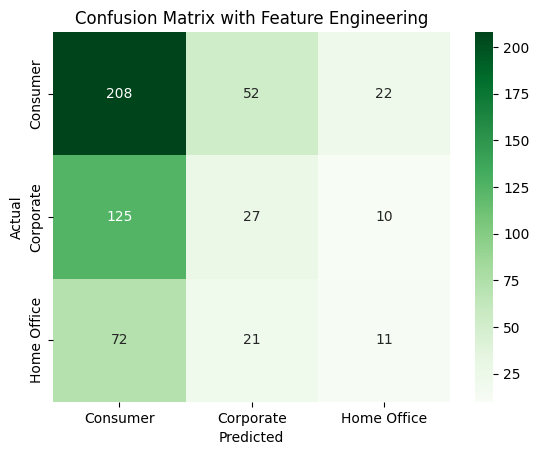

In [35]:

rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\n", classification_report(y_test, y_pred))

conf_mat = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Greens', xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.title("Confusion Matrix with Feature Engineering")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [14:02:11] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.4343065693430657

Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.66      0.58       282
           1       0.31      0.25      0.27       162
           2       0.20      0.12      0.15       104

    accuracy                           0.43       548
   macro avg       0.34      0.34      0.33       548
weighted avg       0.40      0.43      0.41       548



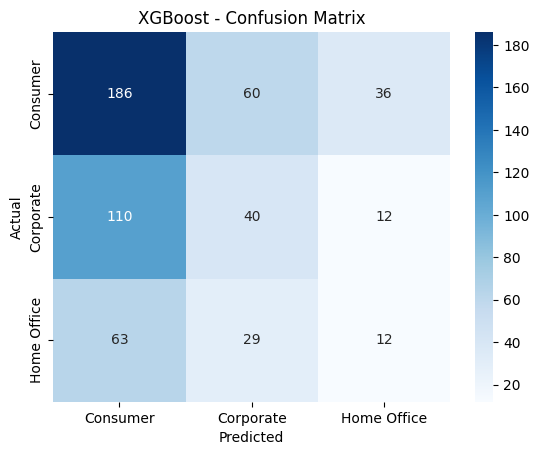

In [43]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Train XGBoost
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test)


# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

# Confusion Matrix
conf_mat_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(conf_mat_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Feature Importance

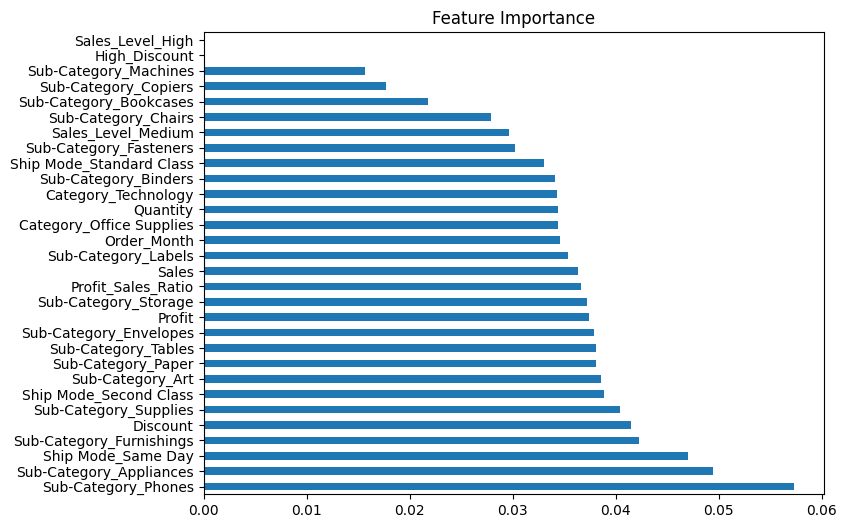

In [44]:
importances = xgb_model.feature_importances_
features = X_train.columns
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)
feat_imp.plot(kind='barh', figsize=(8,6), title='Feature Importance')
plt.show()


Top 10 important features

In [61]:

top_features = feat_imp.head(5).index.tolist()
print("Top 10 Important Features:\n", top_features)


Top 10 Important Features:
 ['Sub-Category_Phones', 'Sub-Category_Appliances', 'Ship Mode_Same Day', 'Sub-Category_Furnishings', 'Discount']


In [62]:
# Check data types of the selected top features

X_top = X_encoded[top_features]
X_top.dtypes

,0
Sub-Category_Phones,bool
Sub-Category_Appliances,bool
Ship Mode_Same Day,bool
Sub-Category_Furnishings,bool
Discount,float64


In [63]:


# Train-test split with stratified sampling
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_top, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [14:52:06] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 Accuracy: 0.5102551275637819

 Classification Report:
               precision    recall  f1-score   support

    Consumer       0.51      1.00      0.68      1021
   Corporate       0.40      0.00      0.01       593
 Home Office       0.00      0.00      0.00       385

    accuracy                           0.51      1999
   macro avg       0.30      0.33      0.23      1999
weighted avg       0.38      0.51      0.35      1999



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


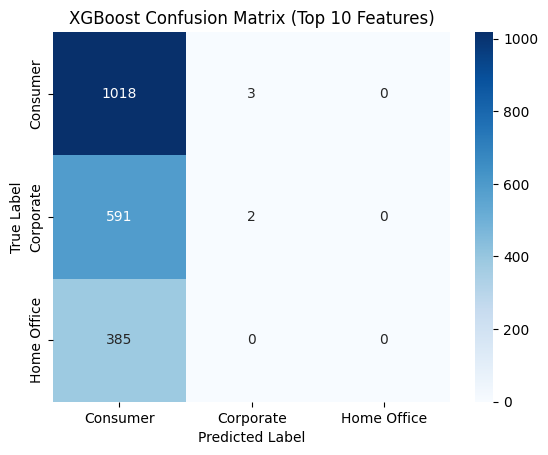

In [79]:
# Step 1: Train the model
xgb_model_top = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_model_top.fit(X_train, y_train)

# Step 2: Predict
y_pred_top = xgb_model_top.predict(X_test)

# Step 3: Evaluation metrics
print(" Accuracy:", (y_pred_top == y_test).mean())
print("\n Classification Report:\n", classification_report(y_test, y_pred_top, target_names=le.classes_))

# Step 4: Confusion matrix with original class labels
cm = confusion_matrix(y_test, y_pred_top)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("XGBoost Confusion Matrix (Top 10 Features)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()